## Week 04 — Decision Boundary Lab

Goal: build a tiny classifier that learns to separate two groups of 2D points.

Each row has two input features:

- `x_position`
- `y_position`

The answer column is:

- `class_label`


In [145]:
from pathlib import Path

def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")
project_root = find_project_root(Path.cwd()).resolve()

### Project root

The notebook finds the project root by looking for `pyproject.toml`.

This keeps saved files going to the repo folders even if Jupyter starts from a different directory.


### Generated 2D dataset

`make_blobs` creates reproducible practice data.

We expect:

- 300 rows
- 3 columns
- two visible clusters
- class `0` mostly near `(-2, -2)`
- class `1` mostly near `(2, 2)`


In [146]:
import pandas as pd
from sklearn.datasets import make_blobs

RANDOM_STATE = 42
LEARNING_RATE = 0.01

data_path = project_root / "data" / "generated" / "week-04-2d-points.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)

# creates 300 labeled 2D points
X, y = make_blobs(
    n_samples=300,
    centers=[(-4.0, -2.0), (3.0, -1.0)],
    cluster_std=0.9,
    random_state=RANDOM_STATE,
)

points = pd.DataFrame(
    {
        "x_position": X[:, 0],
        "y_position": X[:, 1],
        "class_label": y,
    }
)

points.to_csv(data_path, index=False)
print(points.shape)
points.head()

(300, 3)


,x_position,y_position,class_label
0,-5.072173,-1.409102,0
1,-4.489944,-1.900170,0
2,3.108266,-0.537005,1
3,-4.883358,-1.584107,0
4,-3.947612,-3.028673,0


### Dataset check

The dataset shape is `(300, 3)`: 300 points and 3 stored columns.

The notebook display index (`0`, `1`, `2`, ...) is not a CSV column because we save with `index=False`.


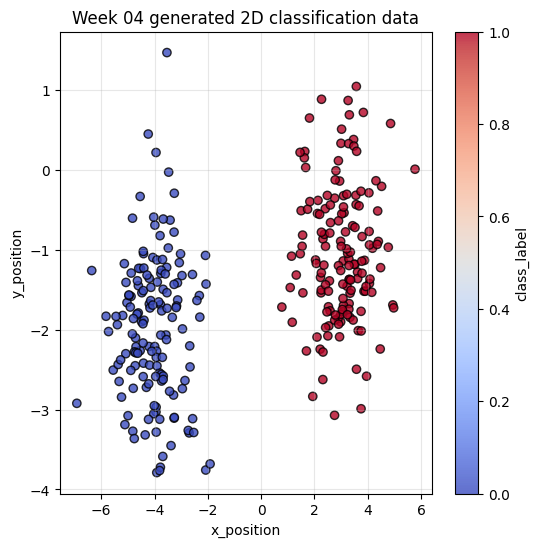

C:\Users\giloz\dev\intuitive_understanding_machine_learning\artifacts\week-04-classification\data_plot.png


In [147]:
import matplotlib.pyplot as plt

artifact_path = project_root / "artifacts" / "week-04-classification" / "data_plot.png"
artifact_path.parent.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(6, 6))

scatter = axis.scatter(
   points["x_position"],
   points["y_position"],
   c=points["class_label"],
   cmap="coolwarm",
   edgecolors="black",
   alpha=0.8,
)

axis.set_title("Week 04 generated 2D classification data")
axis.set_xlabel("x_position")
axis.set_ylabel("y_position")
axis.grid(True, alpha=0.3)

figure.colorbar(scatter, ax=axis, label="class_label")
figure.savefig(artifact_path, dpi=150, bbox_inches="tight")

plt.show()

print(artifact_path)

### Data plot observation

The two classes are clearly separated.

This means a simple straight-line classifier should have a good chance of working.


In [148]:
import numpy as np
from numpy.typing import NDArray

from sklearn.model_selection import train_test_split

FloatArray = NDArray[np.float64]
IntArray = NDArray[np.int64]

features: FloatArray = points[["x_position", "y_position"]].to_numpy(dtype=np.float64)
labels: IntArray = points["class_label"].to_numpy(dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

X_train: (240, 2)
X_test: (60, 2)
y_train: (240,)
y_test: (60,)
Train class counts: [120 120]
Test class counts: [30 30]


### Train/test split

The data was split into:

- 240 training rows
- 60 test rows

`stratify=labels` kept the class balance:

- train: 120 class `0`, 120 class `1`
- test: 30 class `0`, 30 class `1`

`np.bincount` counts how many times each integer label appears.


In [149]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)

X_train_tensor: torch.Size([240, 2]) torch.float32
y_train_tensor: torch.Size([240, 1]) torch.float32
X_test_tensor: torch.Size([60, 2]) torch.float32
y_test_tensor: torch.Size([60, 1]) torch.float32


### Tensor shapes

The model input has shape `(rows, 2)` because each point has two features.

The labels have shape `(rows, 1)` because each row has one binary answer.


In [150]:
from torch import nn

class BinaryLinearClassifier(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.linear = nn.Linear(in_features=2, out_features=1)
    
    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        # score = weight_1 * x_position + weight_2 * y_position + bias
        return self.linear(inputs)

torch.manual_seed(RANDOM_STATE)
model = BinaryLinearClassifier()

print(model)
print(f"Weight shape: {model.linear.weight.shape}")
print(f"Bias shape: {model.linear.bias.shape}")

BinaryLinearClassifier(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
Weight shape: torch.Size([1, 2])
Bias shape: torch.Size([1])


### Linear classifier intuition

`in_features=2` means the model receives two input numbers:

- `x_position`
- `y_position`

The bias is not an input feature. It is an extra learned number.

The model learns:

```text
score = weight_1 * x_position + weight_2 * y_position + bias
```


 The output is a logit. Later we will turn it into:

 - probability near 0 → class 0
 - probability near 1 → class 1

In [151]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

nb_rows = 5
with torch.no_grad():
    first_logits = model(X_train_tensor[:nb_rows])
    first_probabilities = torch.sigmoid(first_logits)


print("First logits:")
print(first_logits)

print("First probabilities:")
print(first_probabilities)

print("True labels:")
print(y_train_tensor[:nb_rows])

First logits:
tensor([[ 0.9583],
        [-2.8163],
        [ 1.0270],
        [-2.6929],
        [ 2.1558]])
First probabilities:
tensor([[0.7228],
        [0.0565],
        [0.7363],
        [0.0634],
        [0.8962]])
True labels:
tensor([[1.],
        [0.],
        [1.],
        [0.],
        [1.]])


In [152]:
with torch.no_grad():
       untrained_logits = model(X_train_tensor)
       untrained_probabilities = torch.sigmoid(untrained_logits)
       untrained_predictions = (untrained_probabilities >= 0.5).to(dtype=torch.float32)
       untrained_accuracy = (untrained_predictions == y_train_tensor).to(dtype=torch.float32).mean()

print("Initial weights:", model.linear.weight)
print("Initial bias:", model.linear.bias)
print("Untrained train accuracy:", untrained_accuracy.item())

Initial weights: Parameter containing:
tensor([[0.5406, 0.5869]], requires_grad=True)
Initial bias: Parameter containing:
tensor([-0.1657], requires_grad=True)
Untrained train accuracy: 0.949999988079071
